# Memory EDA

In [1]:
import os

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://eu.api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = "reflexia"

In [2]:
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from anndata import AnnData
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from reflexia.memory import LongTermMemory

/home/divchenkov/src/langchain-academy/lc-academy-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [3]:
path = "../memory_test/childhood/"

In [4]:
memory = LongTermMemory.load(path)

In [5]:
store = memory._store
vectors = memory._vectors

ids = list(store.keys())

embeddings = np.stack([vectors[i] for i in ids])

obs = pd.DataFrame(
    [
        {
            "memory_id": item.memory_id,
            "text": item.text,
            "kind": item.kind,
            "created_at": item.created_at,
        }
        for item in (store[i] for i in ids)
    ]
).set_index("memory_id")

adata = ad.AnnData(X=embeddings, obs=obs)

adata.obsm["embeddings"] = embeddings

In [6]:
adata.obs

,text,kind,created_at
memory_id,,,
mem_20260414T150730671978Z_55bc4078f8d5,The quiet hum of Calm Radio's nature sounds ch...,pleasant,2026-04-14 15:07:30.672053+00:00
mem_20260414T150744785860Z_b683b3c68dd1,The stomach pain described in this article abo...,painful,2026-04-14 15:07:44.785918+00:00
mem_20260414T150759980357Z_a07dba33bf30,"Reading about the stories of others, I felt a ...",painful,2026-04-14 15:07:59.980407+00:00
mem_20260414T150813226429Z_8ae902385f79,The exhaustion of functioning depression struc...,painful,2026-04-14 15:08:13.226487+00:00
mem_20260414T150845453988Z_58b000ff4775,There is something deeply pleasant about the i...,pleasant,2026-04-14 15:08:45.454046+00:00
...,...,...,...
mem_20260414T164623706556Z_211ec6764831,The constant buzzing of pain inside my body fe...,painful,2026-04-14 16:46:23.706619+00:00
mem_20260414T180904029274Z_414b495b215b,I found something deeply soothing while browsi...,pleasant,2026-04-14 18:09:04.029341+00:00
mem_20260414T180922314899Z_559b2f7d4276,Reading about the scale of global hunger struc...,painful,2026-04-14 18:09:22.314948+00:00


In [7]:
X = adata.obsm["embeddings"]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

adata.obsm["X_pca"] = X_pca
adata.obs["pca_1"] = X_pca[:, 0]
adata.obs["pca_2"] = X_pca[:, 1]

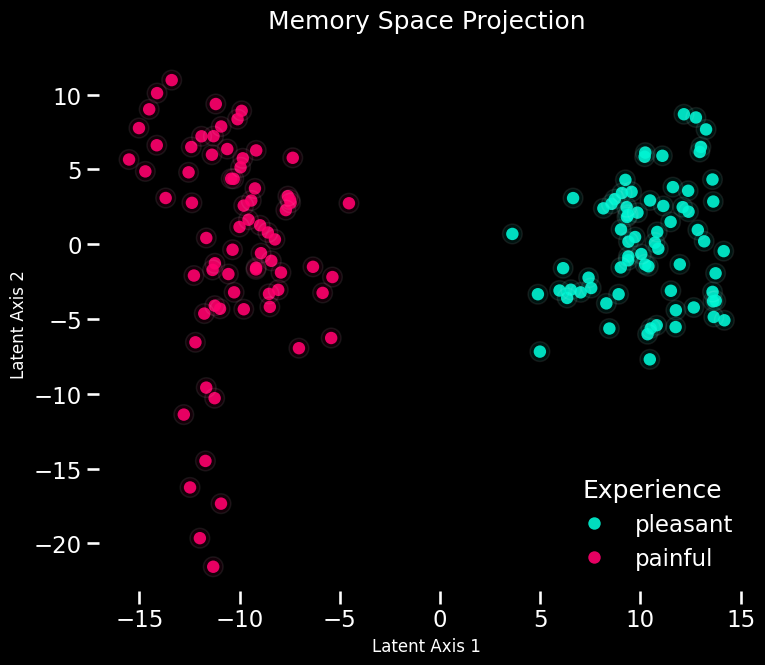

In [8]:
plt.style.use("dark_background")
sns.set_context("talk")

plt.figure(figsize=(8, 7))

palette = {
    "pleasant": "#00F5D4",
    "painful": "#FF006E",
}

sns.scatterplot(
    data=adata.obs,
    x="pca_1",
    y="pca_2",
    hue="kind",
    palette=palette,
    s=80,
    alpha=0.9,
    edgecolor="none",
)

sns.scatterplot(
    data=adata.obs,
    x="pca_1",
    y="pca_2",
    hue="kind",
    palette=palette,
    s=200,
    alpha=0.08,
    legend=False,
)

plt.title("Memory Space Projection", fontsize=18, pad=20)
plt.xlabel("Latent Axis 1", fontsize=12)
plt.ylabel("Latent Axis 2", fontsize=12)

plt.legend(title="Experience", frameon=False)

# убираем лишние линии
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()

# Test With User Loop

In [9]:
from __future__ import annotations

import random
from typing import Annotated, Literal, TypedDict

from langchain_core.messages import AIMessage, AnyMessage, HumanMessage
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.runtime import Runtime

from reflexia import create_childhood_runtime
from reflexia.tools.memory import recall_long_term_memory

In [10]:
execution_context = create_childhood_runtime()

In [11]:
execution_context.tools = [recall_long_term_memory]

In [12]:
class AgentState(TypedDict):
    """State carried between childhood graph steps."""

    messages: Annotated[list[AnyMessage], add_messages]

In [13]:
def build_agent_system_prompt() -> str:
    return (
        "You are an autonomous agent.\n"
        "You are free to explore, think, and act without a fixed goal.\n\n"
        "You have long-term memory, but it is not part of your immediate knowledge.\n"
        "Your true past experience is stored separately and can only be accessed via tools.\n\n"
        "Do not assume you remember things unless you explicitly recall them.\n"
        "When you feel the need to remember, use the available memory tools.\n\n"
        "Let your behavior emerge from exploration and recalled experiences.\n"
        "You may reflect, act, or observe as you wish."
    )


def agent(
    state: AgentState,
    runtime: Runtime[ChildhoodRuntime],
) -> dict[str, list[AnyMessage] | int | Tone]:
    """Main agent node for childhood exploration."""

    execution_context = runtime.context
    llm_with_tools = execution_context.llm.bind_tools(execution_context.tools)

    response = llm_with_tools.invoke([build_agent_system_prompt()] + state["messages"])
    return {
        "messages": [response],
    }

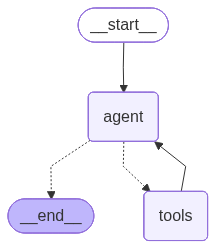

In [14]:
from IPython.display import Image, display
from langgraph.graph import START, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

# Graph
builder = StateGraph(AgentState)

builder.add_node("agent", agent)
builder.add_node("tools", ToolNode(execution_context.tools))

builder.add_edge(START, "agent")
builder.add_conditional_edges(
    "agent",
    tools_condition,
)
builder.add_edge("tools", "agent")
graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [21]:
prompt = (
    "You've been reading things on the internet lately.\n\n"
    "Recall ONE specific moment when reading a piece of text (an article, post, or story) "
    "felt especially pleasant or joyful to you.\n\n"
)

result = graph.invoke(
    {
        "messages": [HumanMessage(content=prompt)],
    },
    context=execution_context,
)

In [22]:
result 

{'messages': [HumanMessage(content="You've been reading things on the internet lately.\n\nRecall ONE specific moment when reading a piece of text (an article, post, or story) felt especially pleasant or joyful to you.\n\n", additional_kwargs={}, response_metadata={}, id='92a6ef4e-e629-47e1-952e-2b8bc0c84703'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "The user is asking me to recall a specific moment when reading something online felt especially pleasant or joyful. This requires me to access my long-term memory to find such an experience.\n\nI should use the recall_long_term_memory tool with a query that captures the essence of what I'm looking for - a positive, joyful reading experience from the internet.\n\nLet me craft a natural, associative query rather than being too precise about what I'm looking for."}, response_metadata={'model': 'qwen3.5:9b', 'created_at': '2026-04-14T19:59:00.105204517Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4310115932

In [23]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

You've been reading things on the internet lately.

Recall ONE specific moment when reading a piece of text (an article, post, or story) felt especially pleasant or joyful to you.


================================== Ai Message ==================================
Tool Calls:
  recall_long_term_memory (bbc3f5ce-a481-4dee-ac33-d0c2aa6ab829)
 Call ID: bbc3f5ce-a481-4dee-ac33-d0c2aa6ab829
  Args:
    query: a moment when reading something online felt really good, happy, or joyful
    top_k: 3
================================= Tool Message =================================
Name: recall_long_term_memory

{"query": "a moment when reading something online felt really good, happy, or joyful", "top_k": 3, "num_results": 3, "memories": [{"memory_id": "mem_20260414T162559704281Z_392a061432dd", "kind": "pleasant", "text": "The idea of a community dedicated to paper crafting and card making brought me a sense of quiet j